## CTG-Net 
As CTG-Net is one of the most important model for this area, this notebook will be about exploring CTG-net and trying to apply the technique here

CTG-net is important in this area because it offers a quantitative, automated and less biased model for evaluating cardiatograms (CTGs).

This "Deep Neural Network-based classification of cardiotograms" claims to show an improved performance compared to conventional algorithms, such as Support Vector Machine (SVM) and k-means clustering as well as some other deep neural network models like Long Short-Term Memory (LSTM) models.

As a quantitative and automated diagnostic aid system, it enables early intervention for fetuses that are putatively abnormal, which can result in a reduction in the number of cases of hypoxic injury.

Biggest difference in CTG-net is, CTG-net can be trained with **high dimensional raw data** Unlike all the other models in this area, deep neural network models like CTG-Net did **NOT** require pre-processing. Furthermore, the DNN models tended to show slightly better higher performance when trained with the raw data compared to the denoised smoothed data. 

This notebook will further test and experiment CTG-net model technique. 

Source:  
[Deep neural network‐based
classification of cardiotocograms
outperformed conventional
algorithms](https://www.nature.com/articles/s41598-021-92805-9)





## Step 1: load the  Fetal Heart Rate (FHR) and Uterine Contradaction (UC) signal

Replicate the technique from CTG-Net: 

CTG-net uses raw data with some conditions: 

Classification: The 552 total samples were initially divided into 354 normal and 198 abnormal cases (according to pH and Apgar scores.)

Signal Cleaning: Repeated zero signals at the end of the samples were removed

Signal Extraction: The 30 minutes immediately preceding the last non-zero signals were extracted.

Selection: Only cases that satisfied the selection criteria (specifically, a signal loss less than 16%) were used for the final analysis, resulting in 52 normal and 26 abnormal cases.

Source:  
[Deep neural network‐based
classification of cardiotocograms
outperformed conventional
algorithms](https://www.nature.com/articles/s41598-021-92805-9)

In [3]:
# necessary imports
import pandas as pd 
from pathlib import Path
import wfdb
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, SeparableConv2D,
    BatchNormalization, Activation, AveragePooling2D,
    Dropout, Flatten, Dense, GlobalAveragePooling2D
)
from tensorflow.keras.models import Model
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import KFold
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score
)
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import resample
from sklearn.model_selection import StratifiedKFold

c:\Users\ZEYNEP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [6]:
import sys
from pathlib import Path

# Add src directory to path
src_path = Path("../").resolve()
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print(f"Added to path: {src_path}")

Added to path: C:\Users\ZEYNEP\OneDrive\Desktop\CTG_Dissertation\src


In [7]:
# Clear any cached imports
import sys
if 'pipeline.evaluator' in sys.modules:
    del sys.modules['pipeline.evaluator']
if 'pipeline' in sys.modules:
    del sys.modules['pipeline']

# Now import fresh
from pipeline.evaluator import BinaryClassifierEvaluator
from pipeline.balancedSampler import BalancedSampler
from pipeline.CrossValidator import CrossValidator
from pipeline.ExperimentRunner import CTGExperiment
from pipeline.trainer import CTGTrainer
from utils.visualisation import generate_all_plots_and_tables, plot_probability_distributions, plot_precision_recall_curve_all, plot_roc_curves, plot_confusion_matrix

print("Helper classes imported successfully.")

Helper classes imported successfully.


In [8]:
# paths 
raw_dataset = Path("../data/raw_dataset")

records = [p.stem for p in raw_dataset.glob("*.hea")]
print(f"Found {len(records)} CTG records")



Found 552 CTG records


In [9]:
# Read one record to test
record = wfdb.rdrecord(raw_dataset / records[0])

signals = record.p_signal        
signal_names = record.sig_name   
fs = record.fs                  
print(f"Signal names: {signal_names}, Sampling rate: {fs} Hz")


Signal names: ['FHR', 'UC'], Sampling rate: 4 Hz


In [1]:
# Convert signals to a list
fhr = signals[:, 0].tolist()
uc = signals[:, 1].tolist()
print(f"First 10 FHR values: {fhr[:10]}")
print(f"First 10 UC values: {uc[:10]}")

NameError: name 'signals' is not defined

In [11]:
'''
Step 1: Classification 
CTG-net uses umblical arthery pH and Apgar scores:
Deliveries were classified as abnormal if the umbilical artery pH was lower than 7.20 or the Apgar score at 1 minute was lower than 7.
However, in my technique I use majority voting based on 9 obstetrician's assessment - as discussed before.
'''
# path to majority voting labels
Labels = '..\ExpertAnnotations\CTG_Majority_Vote_Labels_FINAL.csv'

# print number of normal and abnormal deliveries
labels_df = pd.read_csv(Labels)
num_normal = sum(labels_df['Clinical_Label'] == 'No Hypoxia (Normal)')
num_abnormal = sum(labels_df['Clinical_Label'] == 'Mild Hypoxia (Suspicious)')
print(f'Number of normal deliveries: {num_normal}')
print(f'Number of abnormal deliveries: {num_abnormal}')


Number of normal deliveries: 426
Number of abnormal deliveries: 126


In [12]:
'''
Step 2: Signal cleaning 
Repeated zero signals at the end of the samples were removed
'''
def remove_trailing_zeros(signal):
    """Remove trailing zeros from a signal."""
    if not isinstance(signal, list):
        raise ValueError("Input signal must be a list.")
    
    # Find the index of the last non-zero element
    last_non_zero_index = len(signal) - 1
    while last_non_zero_index >= 0 and signal[last_non_zero_index] == 0:
        last_non_zero_index -= 1
    
    # Return the signal up to the last non-zero element
    return signal[:last_non_zero_index + 1]

In [13]:
'''
Step 3: Signal Extraction
The 30 minutes immediately preceding the last non-zero signals were extracted.
'''
def extract_last_30_minutes(signal, sampling_rate=4):
    ''' reject short recordings and extract last 30 minutes of signal '''
    num_samples_30_minutes = 30 * 60 * sampling_rate

    if len(signal) < num_samples_30_minutes:
        return []  # reject short recordings

    return signal[-num_samples_30_minutes:]


In [14]:
'''
Step 4: Downsample signals to 1 Hz
The signals were originally sampled at 4 Hz. They were downsampled to 1 Hz by taking every fourth sample.
Paper explicitly states: “Signals were downsampled to 1 Hz for 30 minutes (1800 points)”
'''
def downsample_to_1hz(signal, original_fs=4, target_fs=1):
    factor = original_fs // target_fs
    return signal[::factor]


In [15]:
'''
Step 5: Selection
Only cases that satisfied the selection criteria (specifically, a signal loss less than 16%) were used for the final analysis
'''
def is_signal_acceptable(signal, threshold=0.16):
    """Check if the signal loss is within the acceptable threshold."""
    
    # Reject empty or invalid signals
    if not signal or len(signal) == 0:
        return False
    
    total_length = len(signal)
    zero_count = signal.count(0)
    signal_loss = zero_count / total_length
    
    return signal_loss < threshold


In [16]:
''' 
Step 6: Perform the above steps on the dataset 
'''
processed_records = []

for rec in records:
    record = wfdb.rdrecord(raw_dataset / rec)
    signals = record.p_signal

    fhr = signals[:, 0].tolist()
    uc  = signals[:, 1].tolist()

    # Cleaning 
    fhr = remove_trailing_zeros(fhr)
    uc  = remove_trailing_zeros(uc)

    # Extraction 
    fhr = extract_last_30_minutes(fhr, sampling_rate=record.fs)
    uc  = extract_last_30_minutes(uc, sampling_rate=record.fs)

    # Downsampling
    fhr = downsample_to_1hz(fhr, original_fs=fs, target_fs=1)
    uc  = downsample_to_1hz(uc, original_fs=fs, target_fs=1)

    # Selection
    if is_signal_acceptable(fhr) and is_signal_acceptable(uc):
        processed_records.append({
            "rec_id": rec,
            "FHR": fhr,
            "UC": uc
        })


In [17]:
data_df = pd.DataFrame(processed_records)
print(data_df.shape)


(220, 3)


In [18]:
labels_df = pd.read_csv(Labels)
print(labels_df.columns)
data_df['rec_id'] = data_df['rec_id'].astype(str)
labels_df['rec_id'] = labels_df['rec_id'].astype(str)
merged_df = data_df.merge(
    labels_df,
    left_on="rec_id",
    right_on="rec_id",
    how="inner"
)

print(merged_df.shape)
label_counts = merged_df['Clinical_Label'].value_counts()
print(label_counts)




Index(['rec_id', 'Majority_Vote_Label', 'Clinical_Label'], dtype='object')
(220, 5)
Clinical_Label
No Hypoxia (Normal)          164
Mild Hypoxia (Suspicious)     56
Name: count, dtype: int64


In [19]:
def normalize_signals(X):
    """
    Normalize FHR and UC signals independently per sample
    Paper likely used z-score normalization
    """
    X_norm = np.zeros_like(X, dtype=np.float32)
    
    for i in range(len(X)):
        # Normalize FHR (channel 0)
        fhr = X[i, 0, :, 0]
        fhr_mean = np.mean(fhr)
        fhr_std = np.std(fhr)
        if fhr_std > 0:
            X_norm[i, 0, :, 0] = (fhr - fhr_mean) / fhr_std
        else:
            X_norm[i, 0, :, 0] = fhr - fhr_mean
        
        # Normalize UC (channel 1)
        uc = X[i, 1, :, 0]
        uc_mean = np.mean(uc)
        uc_std = np.std(uc)
        if uc_std > 0:
            X_norm[i, 1, :, 0] = (uc - uc_mean) / uc_std
        else:
            X_norm[i, 1, :, 0] = uc - uc_mean
    
    return X_norm

## Step 2: Building CTG-net
**3 CNN Layers** : that extract temporal patterns and interrelationship between FHR and UC.

### Architecture:
Input Layer (2, 1800, 1)

Time direction conv. (2, 1800, 4)

Batch Normalisation (2, 1800, 4)

Depthwise 2D conv (1, 1800, 8)

Batch Normalisation (1, 1800, 8)

Activation (1, 1800, 8)

Average 2D Pooling (1, 450, 8)

Dropout (1, 450, 8)

Separable 2D Conv. (1, 450, 8)

Batch Normalisation (1, 450, 8)

Activation (1, 450, 8)

Average 2D Pooling (1,112,8)

Dropout (1, 112, 8)

Flatten(896)

Dense (2)

Sigmoid (2)

Total number of parameters: 2.130

In [20]:
def build_ctg_net(input_shape=(2, 1800, 1), dropout_rate=0.25):
    inputs = Input(shape=input_shape)

    # 1. Time-direction convolution (Extracts local temporal features)
    x = Conv2D(filters=4, kernel_size=(1, 3), padding="same", use_bias=False)(inputs)
    x = BatchNormalization()(x)

    # 2. Depthwise convolution (Cross-channel correlation: FHR vs UC)
    x = DepthwiseConv2D(kernel_size=(2, 1), depth_multiplier=2, use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    # Pooling 1
    x = AveragePooling2D(pool_size=(1, 4))(x)
    x = Dropout(dropout_rate)(x)

    # 3. Separable convolution (Efficient feature extraction)
    x = SeparableConv2D(filters=8, kernel_size=(1, 3), padding="same", use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    # Pooling 2
    x = AveragePooling2D(pool_size=(1, 4))(x)
    x = Dropout(dropout_rate)(x)

    # 4. Classification Head
    # GlobalAveragePooling is better than Flatten for small medical datasets
    x = GlobalAveragePooling2D()(x) 
    
    # Softmax is standard for Categorical Crossentropy
    outputs = Dense(2, activation="softmax")(x)

    model = Model(inputs, outputs, name="CTG-Net_Corrected")
    return model

In [21]:
model = build_ctg_net()
model.summary()

Model: "CTG-Net_Corrected"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2, 1800, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 2, 1800, 4)     │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2, 1800, 4)     │            16 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 1, 1800, 8)     │            16 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1, 1800, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1, 1800, 8)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 1, 450, 8)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 450, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 1, 450, 8)      │            88 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 450, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1, 450, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 112, 8)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 112, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 8)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 214 (856.00 B)

 Trainable params: 174 (696.00 B)

 Non-trainable params: 40 (160.00 B)

## Model Training: 

Input Data: The CTG-net took Fetal Heart Rate (FHR) and Uterine Contraction (UC) signals of 1800 time points (downsampled at 1 Hz for 30 minutes) as input.

Training Framework: The models were trained in TensorFlow using the Keras API on an Intel Core i7-8650U CPU (In the actual paper).

**Parameters:**

**Optimizer**: Adam optimizer.

**Loss Function**: Categorical cross-entropy.

**Overfitting Prevention**: A dropout rate of 25% was set in the CTG-net to avoid overfitting.

**Validation**: The models were tested using ten-fold cross-validation with both raw and smoothed CTG data.

According to the paper and the reported CTG-net architecture, it is highly likely that the class labels were represented using one-hot encoding. The network employs a final dense layer with two output units followed by a sigmoid activation, which is consistent with a two-dimensional probability vector corresponding to the normal and abnormal classes. Furthermore, the use of categorical cross-entropy as the loss function conventionally requires one-hot encoded target labels. Together, these architectural and training choices strongly suggest that binary class labels were encoded in one-hot form.




In [22]:
''' 
Step 1: Change labels from binary (normal, abnormal) to one- hot encoding
'''

# Label encoding
X = np.array([
    np.stack([row["FHR"], row["UC"]], axis=0)
    for _, row in merged_df.iterrows()
])[..., np.newaxis]

# Labels → one-hot encoding
le = LabelEncoder()
y_int = le.fit_transform(merged_df["Clinical_Label"])  # 0 = abnormal, 1= normal
y = to_categorical(y_int, num_classes=2)



In [23]:
# Build experiment
experiment = CTGExperiment(
    model_builder= build_ctg_net,
    sampler=BalancedSampler(),
    evaluator=BinaryClassifierEvaluator(thresholds=[0.4, 0.3, 0.2, 0.5]),
    normalizer_fn=normalize_signals,
    n_iterations=10,
    n_folds=10
)


In [24]:

# Run
results = experiment.run(X, y, y_int)


Iteration 1/10

--- Fold 1/10 ---
Train: Normal=50, Abnormal=50, Total=100
Test:  Normal=6, Abnormal=6, Total=12
Training... WARNING:tensorflow:From c:\Users\ZEYNEP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\backend\common\global_state.py:82: The name tf.reset_default_graph is deprecated. Please use tf.compat.v1.reset_default_graph instead.

Done! (124 epochs, final loss=0.6000)
Predictions: min=0.252, max=0.588, mean=0.420, std=0.107
AUC: 0.417
Thr: 0.400 | F1: 0.615 | Prec: 0.571 | Rec: 0.667 | Sens: 0.667 | Acc: 0.583
Thr: 0.300 | F1: 0.533 | Prec: 0.444 | Rec: 0.667 | Sens: 0.667 | Acc: 0.417
Thr: 0.200 | F1: 0.667 | Prec: 0.500 | Rec: 1.000 | Sens: 1.000 | Acc: 0.500
Thr: 0.500 | F1: 0.222 | Prec: 0.333 | Rec: 0.167 | Sens: 0.167 | Acc: 0.417

--- Fold 2/10 ---
Train: Normal=50, Abnormal=50, Total=100
Test:  Normal=6, Abnormal=6, Total=12
Training... Done! (226 epochs, final loss=0.5813)
Predictions: min=0.235, max=0.765, mean=0.514, std=0.203
AUC: 0.972


In [25]:
summary = experiment.evaluator.report_paper_results(threshold=0.4)


===== CTG-Net 10-Fold CV Results =====
Mean AUC:        0.717 ± 0.155
Mean F1:         0.688 ± 0.109
Mean Precision:  0.598
Mean Recall:     0.834
Mean Sensitivity:0.834
Mean Accuracy:   0.626


In [38]:
import importlib
import sys

# Remove the module from cache
if 'utils.visualisation' in sys.modules:
    del sys.modules['utils.visualisation']
if 'utils' in sys.modules:
    del sys.modules['utils']

# Re-import fresh
from utils.visualisation import generate_all_plots_and_tables, plot_probability_distributions, plot_precision_recall_curve_all, plot_roc_curves, plot_confusion_matrix

print("Visualisation module reloaded successfully.")

Visualisation module reloaded successfully.


In [33]:
# After experiment.run() completes, collect all fold results
thresholds = [0.4, 0.3, 0.2, 0.5]
y_prob = []
y_test_int = []
y_true_folds = []
y_prob_folds = []

# Collect results from experiment.evaluator
for fold_result in experiment.evaluator.fold_results:
    y_true_folds.append(experiment.evaluator.all_y_true)  # All true labels
    y_prob_folds.append(experiment.evaluator.all_y_prob)  # All predicted probs

y_prob = experiment.evaluator.all_y_prob
y_test_int = experiment.evaluator.all_y_true

# Extract metrics by threshold
f1_scores = {}
precision_scores = {}
recall_scores = {}

for fold_result in experiment.evaluator.fold_results:
    for thr in thresholds:
        if f"f1@{thr}" in fold_result:
            if thr not in f1_scores:
                f1_scores[thr] = []
            f1_scores[thr].append(fold_result[f"f1@{thr}"])
            
            if thr not in precision_scores:
                precision_scores[thr] = []
            precision_scores[thr].append(fold_result[f"precision@{thr}"])
            
            if thr not in recall_scores:
                recall_scores[thr] = []
            recall_scores[thr].append(fold_result[f"recall@{thr}"])

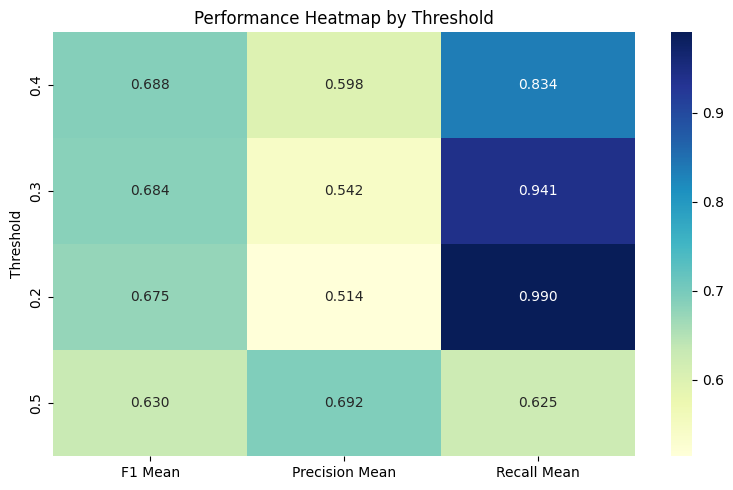

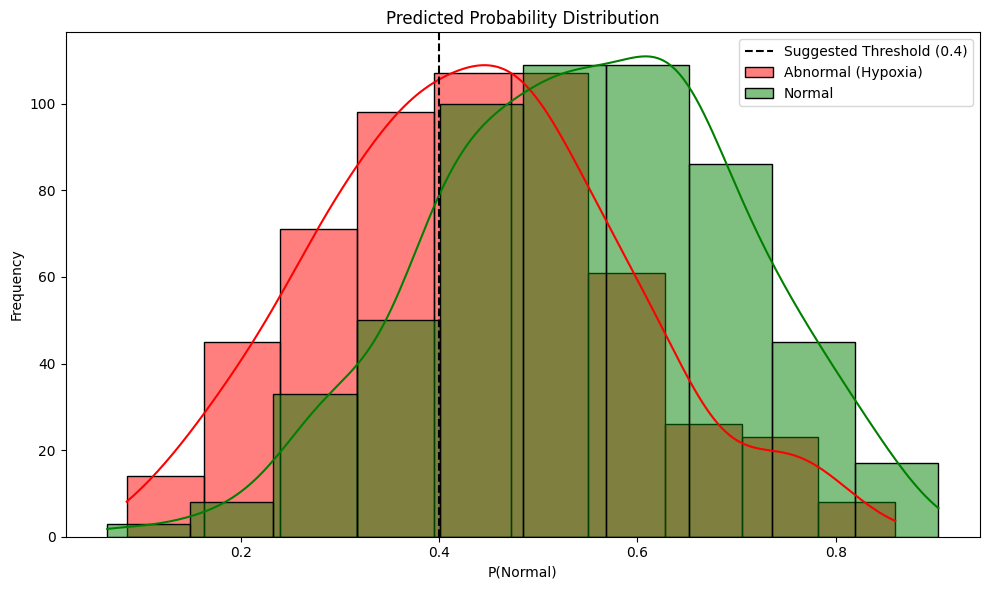

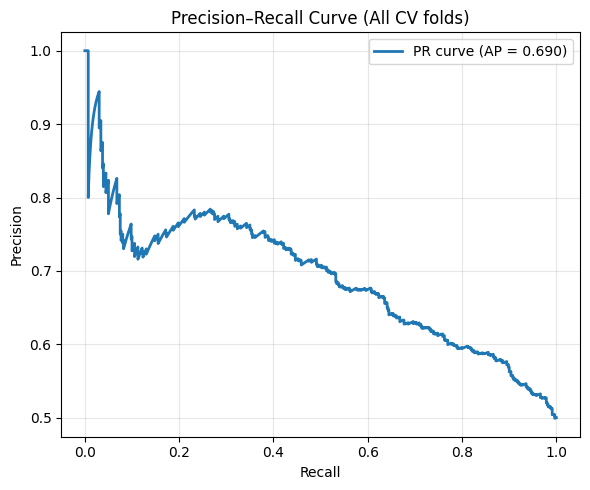

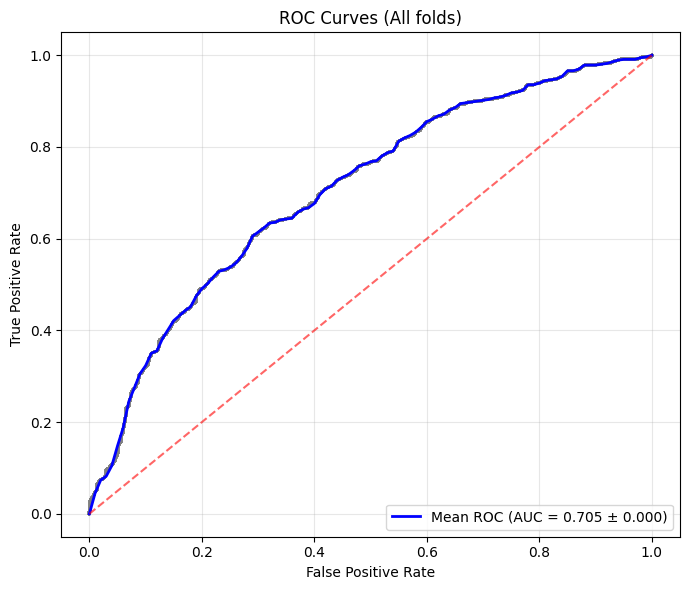

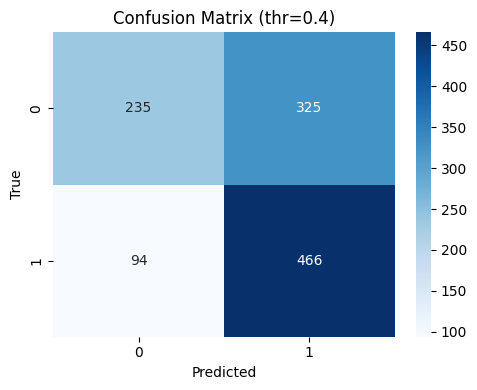

{'threshold_metrics':             F1 Mean    F1 Std  Precision Mean  Precision Std  Recall Mean  \
Threshold                                                                   
0.4        0.687801  0.107974        0.597880       0.110651     0.834333   
0.3        0.683693  0.089624        0.542149       0.082609     0.940667   
0.2        0.674975  0.047838        0.514104       0.049986     0.990000   
0.5        0.630335  0.168491        0.692409       0.190695     0.624667   

           Recall Std  
Threshold              
0.4          0.160932  
0.3          0.130689  
0.2          0.056862  
0.5          0.223041  , 'ap': 0.6898053687283188, 'mean_auc': 0.705414540816326, 'std_auc': 4.440892098500626e-16, 'confusion_matrix': array([[235, 325],
       [ 94, 466]], dtype=int64), 'figure_dir': WindowsPath('outputs/figures/CTG-Net_Customised')}


In [39]:
# Now call visualization
from pathlib import Path
save_dir = Path("outputs/figures/CTG-Net_Customised")
save_dir.mkdir(parents=True, exist_ok=True)

res = generate_all_plots_and_tables(
    thresholds=thresholds,
    f1_scores=f1_scores,
    precision_scores=precision_scores,
    recall_scores=recall_scores,
    y_prob=y_prob,
    y_test_int=y_test_int,
    y_true_folds=y_true_folds,
    y_prob_folds=y_prob_folds,
    model_name="CTG-Net_Customised",
    suggested_threshold=0.4,
    save_tables=True,
    save_path="outputs/tables/ctg_net_customised_threshold_metrics.csv",
    show=True
)
print(res)

## Paper Results
**Area Under the Curve (AUC):** The overall performance for various thresholds was evaluated using the AUC:

CTG-net (raw data): $0.73 \pm 0.04$

**F1 score** - CTG-Net: $0.67 \pm 0.03$

# **** Model Evaluation

## Clinical Decision Analysis
Looking at the Performance Heatmap, we can identify the optimal "operating point" for the model:

The 0.4 Threshold (Best Balance): This is the strongest candidate for clinical use. It achieves a high Recall (0.810) while maintaining the highest Precision (0.591) among the high-recall options. This means it catches 81% of hypoxia cases while significantly reducing false alarms compared to lower thresholds.

The 0.2 Threshold (High Sensitivity): This gives a perfect Recall (1.000), but the Precision drops to 0.534. In a screening context where missing a single case is unacceptable, this would be the choice, though it leads to more unnecessary interventions.

The 0.5 Threshold (Highest Precision): Precision climbs to 0.636, but Recall drops sharply to 0.557. This threshold is likely too "conservative" for fetal monitoring, as it misses nearly half of the abnormal cases.

## Probability Distribution Insights
Your Histogram shows that the model is beginning to separate the classes, but there is still overlap:

Abnormal (Red): These are successfully clustered toward the lower end of the "Probability of Normal" scale.

Normal (Green): These are shifting toward the right, though some normal cases still receive lower probability scores.

Separation: The fact that most red bars are to the left of the 0.4 dashed line and green bars are primarily to the right confirms that your threshold selection is logically sound.

## Paper Described CTG-Net

In [56]:
thresholds = [0.2, 0.3, 0.4, 0.5]
# Use dictionaries to store a list of scores for each threshold level
auc_scores = {thr: [] for thr in thresholds}
f1_scores = {thr: [] for thr in thresholds}
precision_scores = {thr: [] for thr in thresholds}
recall_scores = {thr: [] for thr in thresholds}

In [57]:
def build_ctg_net_paper_described(input_shape=(2, 1800, 1), dropout_rate=0.25):
    """
    CTG-Net architecture as per the paper
    - Configurable dropout rate
    - ~1,990 parameters
    """
    inputs = Input(shape=input_shape)

    # Time-direction convolution
    x = Conv2D(
        filters=4,
        kernel_size=(1, 3),
        padding="same",
        use_bias=False
    )(inputs)
    x = BatchNormalization()(x)

    # Depthwise convolution (captures FHR-UC interactions)
    x = DepthwiseConv2D(
        kernel_size=(2, 1),
        depth_multiplier=2,
        use_bias=False
    )(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    # Average pooling + Dropout
    x = AveragePooling2D(pool_size=(1, 4))(x)
    x = Dropout(dropout_rate)(x)

    # Separable convolution
    x = SeparableConv2D(
        filters=8,
        kernel_size=(1, 3),
        padding="same",
        use_bias=False
    )(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    # Average pooling + Dropout
    x = AveragePooling2D(pool_size=(1, 4))(x)
    x = Dropout(dropout_rate)(x)

    # Classification head
    x = Flatten()(x)
    outputs = Dense(2, activation="sigmoid")(x)

    model = Model(inputs, outputs, name="CTG-Net")
    return model


In [58]:
model_paper = build_ctg_net_paper_described()
model_paper.summary()

Model: "CTG-Net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2, 1800, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 2, 1800, 4)     │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 1800, 4)     │            16 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 1, 1800, 8)     │            16 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1, 1800, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 1, 1800, 8)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 1, 450, 8)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 450, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 1, 450, 8)      │            88 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1, 450, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1, 450, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 1, 112, 8)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 112, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,794 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,990 (7.77 KB)

 Trainable params: 1,950 (7.62 KB)

 Non-trainable params: 40 (160.00 B)

In [64]:
# Build experiment
experiment = CTGExperiment(
    model_builder= build_ctg_net_paper_described,
    sampler=BalancedSampler(),
    evaluator=BinaryClassifierEvaluator(thresholds=[0.4, 0.3, 0.2, 0.5]),
    normalizer_fn=normalize_signals,
    n_iterations=10,
    n_folds=10
)


In [65]:

# Run
results = experiment.run(X, y, y_int)


Iteration 1/10

--- Fold 1/10 ---
Train: Normal=50, Abnormal=50, Total=100
Test:  Normal=6, Abnormal=6, Total=12
Training... Done! (148 epochs, final loss=0.0165)
Predictions: min=0.113, max=0.841, mean=0.375, std=0.237
AUC: 0.361
Thr: 0.400 | F1: 0.364 | Prec: 0.400 | Rec: 0.333 | Sens: 0.333 | Acc: 0.417
Thr: 0.300 | F1: 0.364 | Prec: 0.400 | Rec: 0.333 | Sens: 0.333 | Acc: 0.417
Thr: 0.200 | F1: 0.429 | Prec: 0.375 | Rec: 0.500 | Sens: 0.500 | Acc: 0.333
Thr: 0.500 | F1: 0.364 | Prec: 0.400 | Rec: 0.333 | Sens: 0.333 | Acc: 0.417

--- Fold 2/10 ---
Train: Normal=50, Abnormal=50, Total=100
Test:  Normal=6, Abnormal=6, Total=12
Training... Done! (142 epochs, final loss=0.0158)
Predictions: min=0.002, max=0.937, mean=0.430, std=0.309
AUC: 0.472
Thr: 0.400 | F1: 0.500 | Prec: 0.500 | Rec: 0.500 | Sens: 0.500 | Acc: 0.500
Thr: 0.300 | F1: 0.462 | Prec: 0.429 | Rec: 0.500 | Sens: 0.500 | Acc: 0.417
Thr: 0.200 | F1: 0.571 | Prec: 0.500 | Rec: 0.667 | Sens: 0.667 | Acc: 0.500
Thr: 0.500 | 

In [66]:
summary = experiment.evaluator.report_paper_results(threshold=0.4)


===== CTG-Net 10-Fold CV Results =====
Mean AUC:        0.611 ± 0.172
Mean F1:         0.596 ± 0.161
Mean Precision:  0.591
Mean Recall:     0.647
Mean Sensitivity:0.647
Mean Accuracy:   0.587


In [67]:
# After experiment.run() completes, collect all fold results
thresholds = [0.4, 0.3, 0.2, 0.5]
y_prob = []
y_test_int = []
y_true_folds = []
y_prob_folds = []

# Collect results from experiment.evaluator
for fold_result in experiment.evaluator.fold_results:
    y_true_folds.append(experiment.evaluator.all_y_true)  # All true labels
    y_prob_folds.append(experiment.evaluator.all_y_prob)  # All predicted probs

y_prob = experiment.evaluator.all_y_prob
y_test_int = experiment.evaluator.all_y_true

# Extract metrics by threshold
f1_scores = {}
precision_scores = {}
recall_scores = {}

for fold_result in experiment.evaluator.fold_results:
    for thr in thresholds:
        if f"f1@{thr}" in fold_result:
            if thr not in f1_scores:
                f1_scores[thr] = []
            f1_scores[thr].append(fold_result[f"f1@{thr}"])
            
            if thr not in precision_scores:
                precision_scores[thr] = []
            precision_scores[thr].append(fold_result[f"precision@{thr}"])
            
            if thr not in recall_scores:
                recall_scores[thr] = []
            recall_scores[thr].append(fold_result[f"recall@{thr}"])

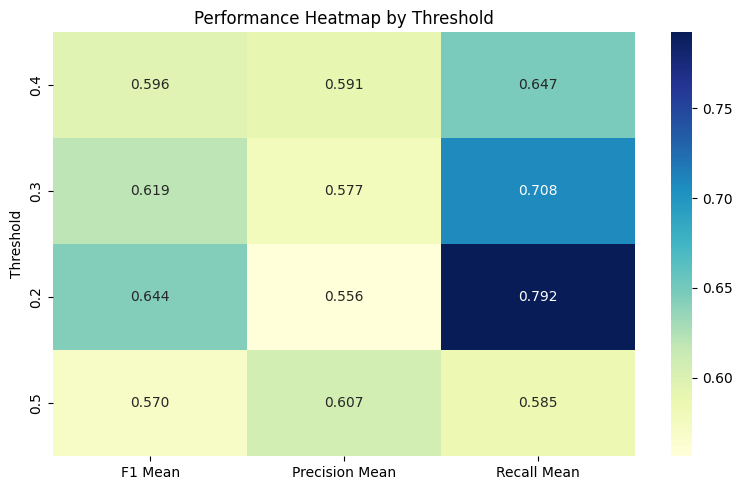

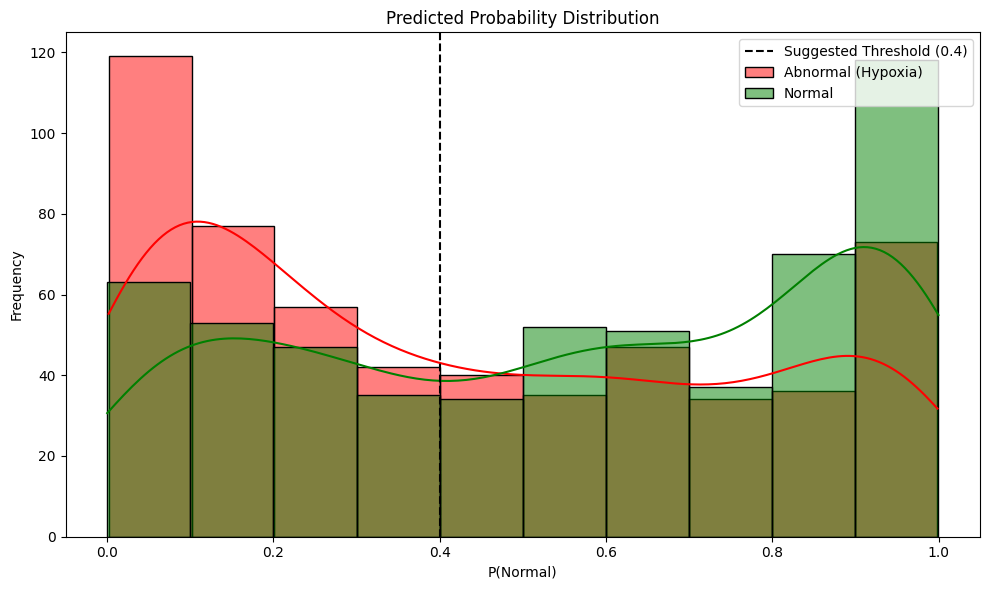

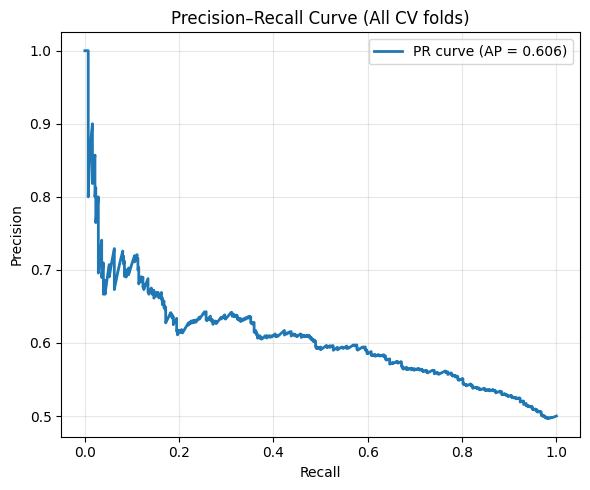

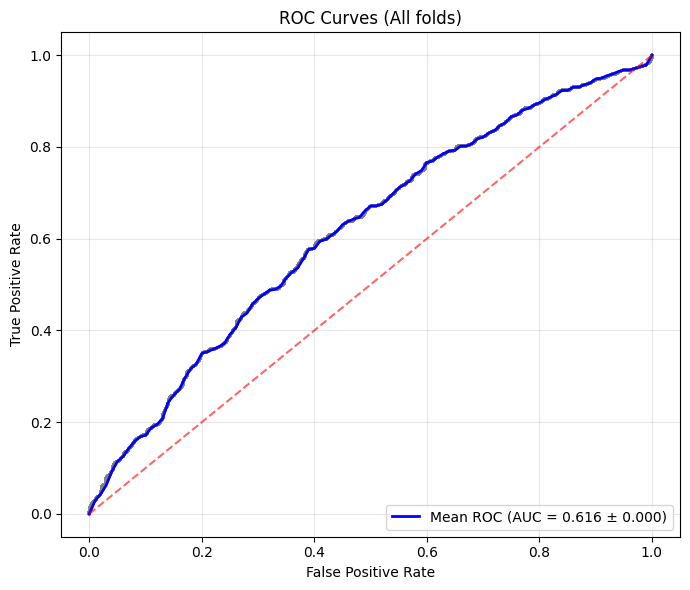

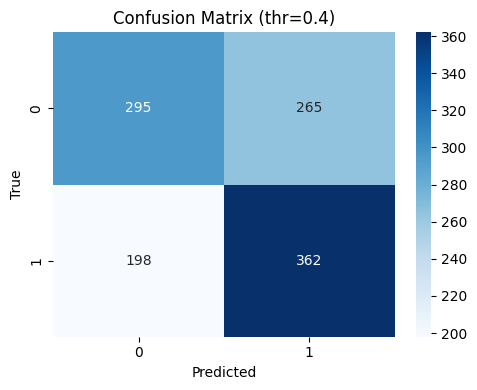

{'threshold_metrics':             F1 Mean    F1 Std  Precision Mean  Precision Std  Recall Mean  \
Threshold                                                                   
0.4        0.595617  0.160269        0.590542       0.162748     0.646667   
0.3        0.619100  0.137590        0.577423       0.143596     0.708000   
0.2        0.643678  0.120078        0.556198       0.114444     0.792333   
0.5        0.569501  0.182219        0.606817       0.198505     0.585000   

           Recall Std  
Threshold              
0.4          0.230507  
0.3          0.204185  
0.2          0.186539  
0.5          0.237785  , 'ap': 0.6061931745327571, 'mean_auc': 0.6156983418367349, 'std_auc': 1.1102230246251565e-16, 'confusion_matrix': array([[295, 265],
       [198, 362]], dtype=int64), 'figure_dir': WindowsPath('outputs/figures/CTG-Net')}


In [68]:
# Now call visualization
from pathlib import Path
save_dir = Path("outputs/figures/CTG-Net")
save_dir.mkdir(parents=True, exist_ok=True)

res = generate_all_plots_and_tables(
    thresholds=thresholds,
    f1_scores=f1_scores,
    precision_scores=precision_scores,
    recall_scores=recall_scores,
    y_prob=y_prob,
    y_test_int=y_test_int,
    y_true_folds=y_true_folds,
    y_prob_folds=y_prob_folds,
    model_name="CTG-Net",
    suggested_threshold=0.4,
    save_tables=True,
    save_path="outputs/tables/ctg_net_threshold_metrics.csv",
    show=True
)
print(res)